In [93]:
# Standard libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Sklearn - preprocessing
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.preprocessing import LabelEncoder,OneHotEncoder,StandardScaler

# Sklearn - models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Sklearn - metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score,confusion_matrix,roc_auc_score,roc_curve, ConfusionMatrixDisplay

# Save Model
import joblib

# Load Data

In [2]:
telecom = pd.read_excel('Telco_customer_churn.xlsx')
complaints = pd.read_csv('complaints.csv')
offers = pd.read_csv('offers.csv')

In [3]:
telecom.shape

(7043, 33)

In [4]:
complaints.shape

(2226, 6)

In [5]:
offers.shape

(1074, 6)

# Data Cleaning

### check columns

In [6]:
telecom.columns

Index(['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code',
       'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen',
       'Partner', 'Dependents', 'Tenure Months', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value',
       'Churn Score', 'CLTV', 'Churn Reason'],
      dtype='object')

In [7]:
complaints.columns

Index(['Unnamed: 0', 'TicketID', 'CustomerID', 'IssueType', 'ResolutionTime',
       'Status'],
      dtype='object')

In [8]:
offers.columns

Index(['Unnamed: 0', 'OfferID', 'CustomerID', 'OfferType', 'DiscountValue',
       'Accepted'],
      dtype='object')

### Dropping irrelevant features

In [9]:
# Count, Zip Code, Lat Long, Latitude, Longitude: geographical - not useful for churn prediction
# Churn Score, CLTV, Churn Reason: data leakage - directly related to churn

telecom_irr_features = ['Count','Zip Code','Lat Long','Latitude','Longitude','Device Protection','Churn Score','CLTV','Churn Reason']
complaints_irr_features = ['Unnamed: 0']
offers_irr_features = ['Unnamed: 0']

In [10]:
telecom.drop(columns=telecom_irr_features,inplace=True)
complaints.drop(columns=complaints_irr_features,inplace=True)
offers.drop(columns=offers_irr_features,inplace=True)

### Check Missing Values 

In [11]:
def check_missing_values(df):
    missing = df.isna().sum()
    if missing[missing > 0].sum() > 0:
        return missing
    else:
        return "no missing values"

In [12]:
telecom_missing = check_missing_values(telecom)
print(f"telecom dataset : {telecom_missing}")

telecom dataset : no missing values


In [13]:
complaints_missing = check_missing_values(complaints)
print(f"complaints dataset : {complaints_missing}")

complaints dataset : no missing values


In [14]:
offers_missing = check_missing_values(offers)
print(f"offers dataset : {offers_missing}")

offers dataset : no missing values


### Feature PreProcessing

In [15]:
def format_total_charges(df):
    # Convert to numeric, invalid values become NaN
    df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')

    # Drop rows where Total Charges couldn't be converted
    df.dropna(subset=['Total Charges'], inplace=True)
    return df

In [16]:
telecom = format_total_charges(telecom)
print(telecom['Total Charges'].dtype)

float64


### check Outliers

In [17]:
def check_outliers(df,y_title,title):
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=df,
                y=y_title,
                color='#2196F3')
    plt.title(title)
    plt.show()

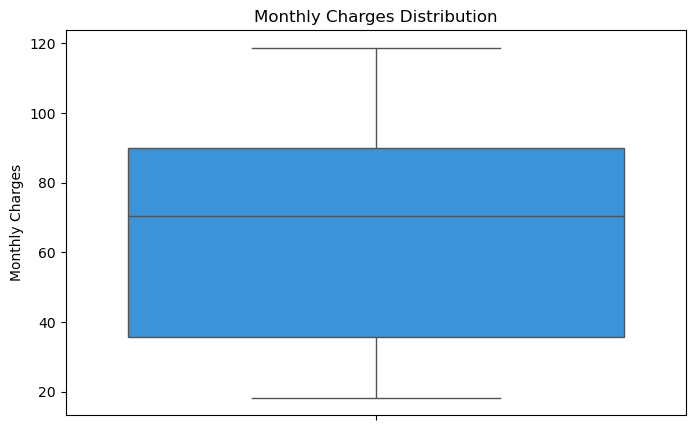

In [18]:
# No significant outliers - data is normally distributed between 20-120
check_outliers(telecom,'Monthly Charges','Monthly Charges Distribution')

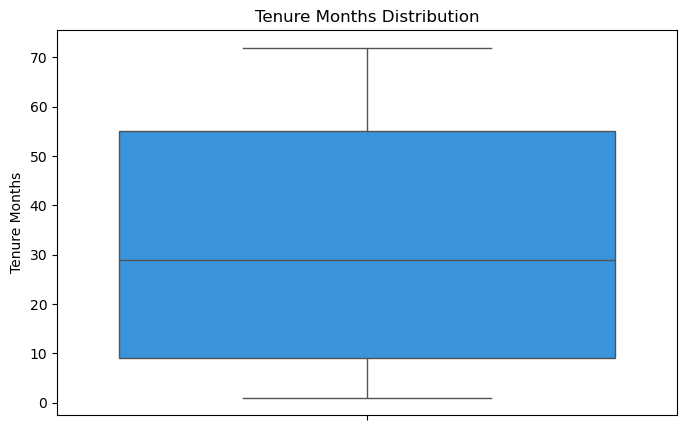

In [19]:
# No significant outliers - data is normally distributed between 0-70
check_outliers(telecom,'Tenure Months','Tenure Months Distribution')

# EDA

In [20]:
def to_dataframe(series):
    series = series.round(2)
    df = pd.DataFrame(series)
    return df

### Contract


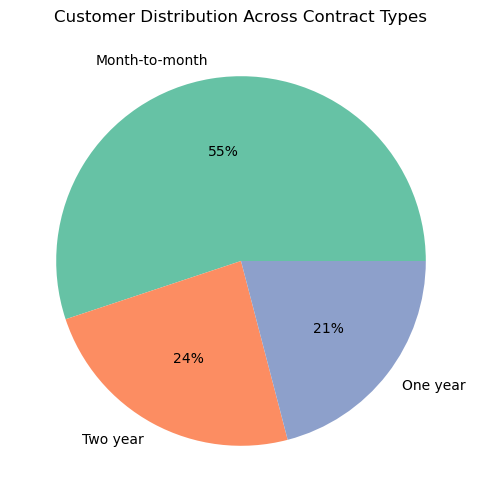

In [21]:
# 55% of customers are on month-to-month contracts

colors = sns.color_palette('Set2', 3)
plt.figure(figsize=(6,6))
plt.pie(telecom['Contract'].value_counts(),
        labels=telecom['Contract'].unique(),
        autopct='%.0f%%',
        colors=colors)
plt.title('Customer Distribution Across Contract Types')
plt.show()

### Contract vs Churn

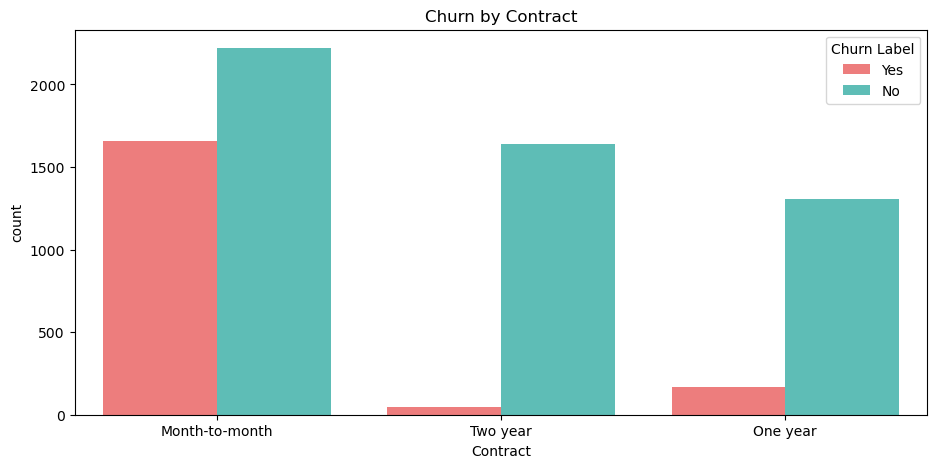

In [22]:
# Month-to-month: ~42% churn rate (1650 Yes vs 2250 No) → very high risk
# Two year: ~2% churn rate → very loyal customers  
# One year: ~11% churn rate → moderate risk

plt.figure(figsize=(11, 5))
sns.countplot(data=telecom, 
              x='Contract', 
              hue='Churn Label',
             palette={'Yes': '#FF6B6B', 'No': '#4ECDC4'})
plt.title('Churn by Contract')
plt.show()

### Payment Method

In [23]:
# Electronic check dominates at 33%
# Automatic payments (Bank transfer + Credit card) ~43% combined

payment_method_share = telecom['Payment Method'].value_counts(normalize=True)*100
payment_method_share.name = 'Percentage %'
to_dataframe(payment_method_share)

,Percentage %
Payment Method,
Electronic check,33.63
Mailed check,22.81
Bank transfer (automatic),21.93
Credit card (automatic),21.63


### Payment Method vs Churn

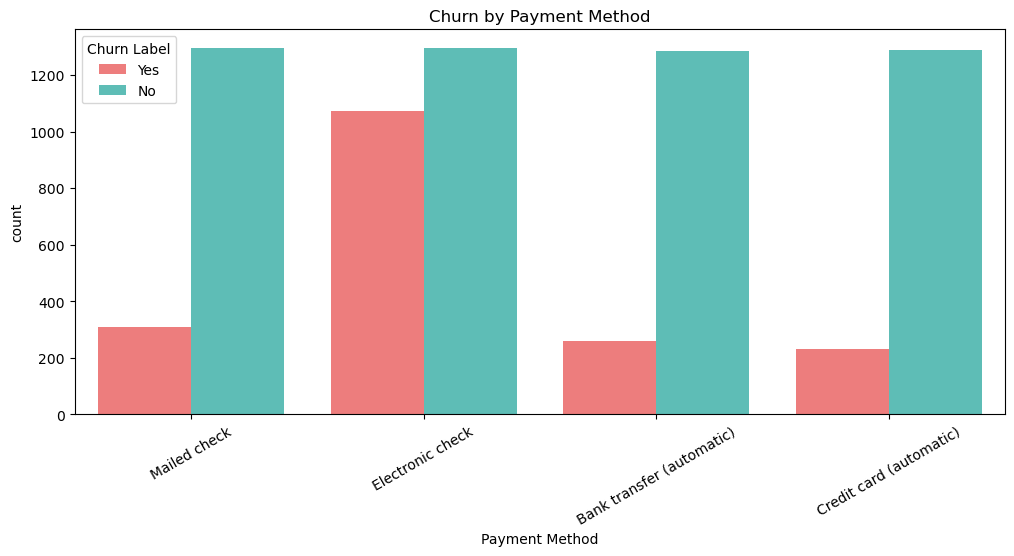

In [24]:
# Electronic check: Yes is closest to No → highest churn risk
# Mailed check & Bank transfer & Credit card: Yes is far from No → lowest churn risk

plt.figure(figsize=(12,5))
sns.countplot(data=telecom,
             x='Payment Method',
             hue='Churn Label',
             palette={'Yes': '#FF6B6B', 'No': '#4ECDC4'})
plt.title('Churn by Payment Method')
plt.xticks(rotation=30)
plt.show()

### Tenure Months (Month to Month Contract)

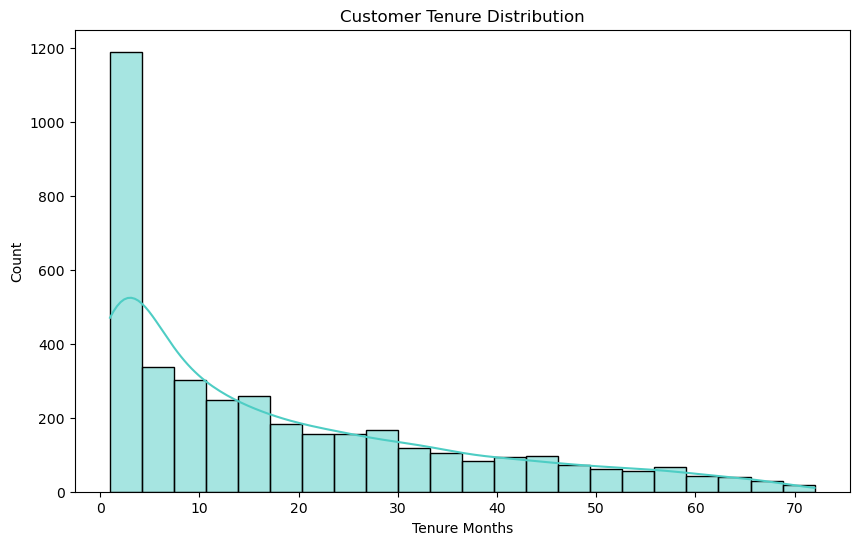

In [25]:
# Month-to-month customers with low tenure churn more than those with high tenure
# Most month-to-month customers leave within the first 3 months
# Very few stay beyond 50 months → early churn is the biggest risk

plt.figure(figsize=(10, 6))
monthly_contract = telecom[telecom['Contract']=='Month-to-month']
sns.histplot(data=monthly_contract,
             x='Tenure Months',
             kde=True, 
             color='#4ECDC4')
plt.title('Customer Tenure Distribution')
plt.show()

### Internet Services

In [26]:
# Fiber optic is the most common service at 44%
# 22% of customers have no internet service

internet_services_share = telecom['Internet Service'].value_counts(normalize=True)*100
internet_services_share.name = 'Percentage %'
to_dataframe(internet_services_share)

,Percentage %
Internet Service,
Fiber optic,44.03
DSL,34.36
No,21.62


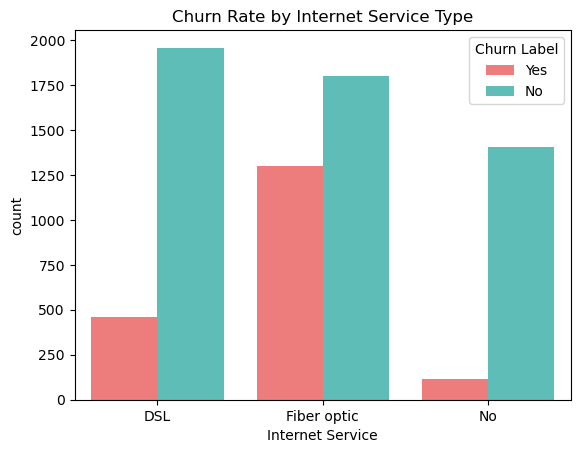

In [27]:
# Fiber optic: very high churn risk
# DSL: moderate churn risk
# No internet: lowest churn risk

sns.countplot(data=telecom,
              x='Internet Service',
              hue='Churn Label',
              palette={'Yes': '#FF6B6B', 'No': '#4ECDC4'})
plt.title('Churn Rate by Internet Service Type')
plt.show()

In [28]:
# Top churn risk profile: Month-to-month contract + Fiber optic + Electronic check
# This single combination accounts for 42% of all churned customers
# Recommendation: Target this group with retention offers first

churn_combo = (telecom.groupby(['Contract','Internet Service','Payment Method'])['Churn Value'].sum()*100 /
 telecom[telecom['Churn Label']=='Yes'].shape[0]).sort_values(ascending=False)
churn_combo.name = 'Churn Percentage %'

to_dataframe(churn_combo)

Churn Percentage %
Contract       Internet Service Payment Method                               
Month-to-month Fiber optic      Electronic check                        42.22
               DSL              Electronic check                        10.27
               Fiber optic      Bank transfer (automatic)                7.97
                                Credit card (automatic)                  6.53
               DSL              Mailed check                             6.05
               Fiber optic      Mailed check                             5.46
               No               Mailed check                             3.58
One year       Fiber optic      Electronic check                         2.73
Month-to-month DSL              Credit card (automatic)                  2.68
                                Bank transfer (automatic)                2.09
One year       Fiber optic      Bank transfer (automatic)                1.23
                                Credit card (automatic)                  1.23
               DSL              Credit card (automatic)                  0.91
Two year       Fiber optic      Bank transfer (automatic)                0.80
One year       DSL              Mailed check                             0.75
Month-to-month No               Electronic check                         0.70
                                Bank transfer (automatic)                0.70
One year       DSL              Bank transfer (automatic)                0.59
                                Electronic check                         0.59
Two year       Fiber optic      Electronic check                         0.48
One year       Fiber optic      Mailed check                             0.37
Month-to-month No               Credit card (automatic)                  0.32
Two year       Fiber optic      Credit card (automatic)                  0.32
               DSL              Credit card (automatic)                  0.27
One year       No               Bank transfer (automatic)                0.21
Two year       DSL              Electronic check                         0.21
                                Bank transfer (automatic)                0.16
               No               Credit card (automatic)                  0.11
One year       No               Mailed check                             0.11
                                Electronic check                         0.11
Two year       No               Mailed check                             0.11
               Fiber optic      Mailed check                             0.05
               No               Bank transfer (automatic)                0.05
One year       No               Credit card (automatic)                  0.05
Two year       DSL              Mailed check                             0.00
               No               Electronic check                         0.00

## Do month-to-month customers pay more than other contract types?

In [29]:
# Month-to-month: $66.40 vs Two year: $60.77 → only $5.6 difference
# The small price difference may not be enough incentive to switch to longer contracts
# Recommendation: Offer bigger discounts on annual contracts to reduce churn

contract_monthly_charges = telecom.groupby('Contract')['Monthly Charges'].mean()
to_dataframe(contract_monthly_charges)

,Monthly Charges
Contract,
Month-to-month,66.40
One year,65.08
Two year,60.87


### Total Charges

C:\Users\Lenovo LOQ\AppData\Local\Temp\ipykernel_30152\989005008.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=telecom,


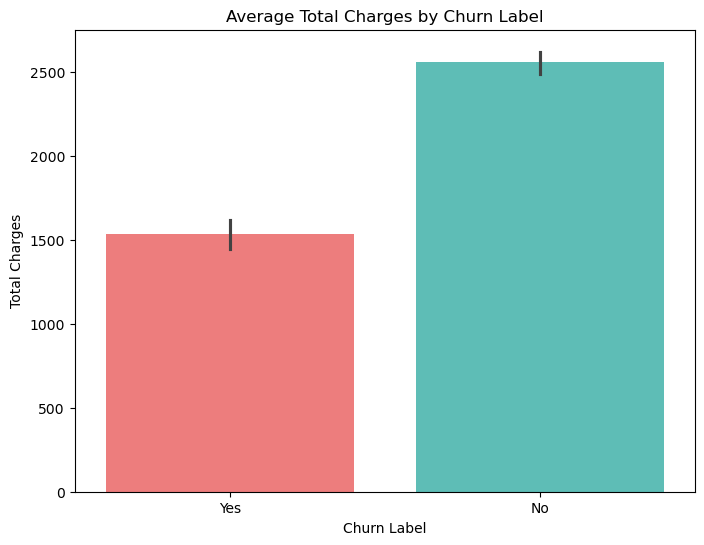

In [30]:
# Churned customers (Yes) paid ~$1500 on average vs ~$2500 for retained customers
# Customers who stay longer naturally pay more total charges
# Insight: early churn = significant revenue loss per customer

plt.figure(figsize=(8, 6))
sns.barplot(data=telecom,
            x='Churn Label',
            y='Total Charges',
           palette={'Yes': '#FF6B6B', 'No': '#4ECDC4'})
plt.title('Average Total Charges by Churn Label')
plt.show()

### Complaints Analysis

In [31]:
customers_complaints = telecom.merge(complaints, on='CustomerID', how='inner')

In [32]:
# Month-to-month customers generate 68% of complaints 
# High complaint rate is likely one of the key drivers of their churn
# More dissatisfied customers → more likely to leave

customers_complaints_contract_share = customers_complaints['Contract'].value_counts(normalize=True)*100
customers_complaints_contract_share.name = 'Percentage %'
to_dataframe(customers_complaints_contract_share)

,Percentage %
Contract,
Month-to-month,68.17
Two year,16.82
One year,15.02


C:\Users\Lenovo LOQ\AppData\Local\Temp\ipykernel_30152\3061448917.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=customers_complaints,


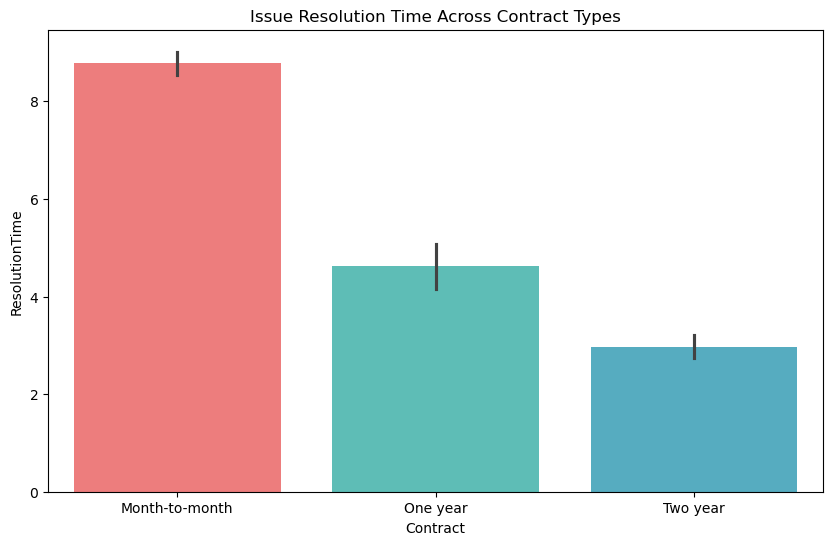

In [33]:
# Month-to-month customers wait ~9 days for issue resolution vs ~3 days for two-year customers
# Poor support experience is another key driver of churn for monthly customers
# Recommendation: Prioritize support for month-to-month customers to reduce churn

plt.figure(figsize=(10, 6))
sns.barplot(data=customers_complaints,
            x='Contract',
            y='ResolutionTime',
            palette=['#FF6B6B', '#4ECDC4', '#45B7D1'],
            order=['Month-to-month','One year','Two year'])
plt.title('Issue Resolution Time Across Contract Types')
plt.show()

### Offers Analysis

In [34]:
customers_offers = telecom.merge(offers, on='CustomerID', how='inner')

In [35]:
# 73% of customers who received offers are on month-to-month contracts
# Despite receiving offers, this group still has the highest churn rate
# Insight: offers alone aren't enough — may need better targeting or offer types

customers_offers_contract_share = customers_offers['Contract'].value_counts(normalize=True)*100
customers_offers_contract_share.name = 'Offer Used Percentage %'
to_dataframe(customers_offers_contract_share)

,Offer Used Percentage %
Contract,
Month-to-month,73.44
One year,13.70
Two year,12.86


# Feature Engineering

In [36]:
# UnBalanced Labels: 73% No vs 27% Yes

churn_label_share = telecom['Churn Label'].value_counts(normalize=True)*100
churn_label_share.name = 'Percentage %'
to_dataframe(churn_label_share)

,Percentage %
Churn Label,
No,73.42
Yes,26.58


In [37]:
# Selected features based on EDA insights:
# - Tenure Months, Contract: strong churn predictors (month-to-month + low tenure = high risk)
# - Monthly Charges, Payment Method: linked to churn rate (electronic check = high risk)
# - Internet Service: fiber optic = high churn risk
# - Online Security, Online Backup, Tech Support: service quality indicators

X = telecom[['Tenure Months','Monthly Charges','Contract','Payment Method',
                    'Internet Service','Online Security','Online Backup','Tech Support']]

# Target variable
y = telecom['Churn Label']

## Encoding For Categorical Features

In [38]:
# Encode: Yes → 1, No → 0
labelEncoder = LabelEncoder()
y = labelEncoder.fit_transform(y)

In [39]:
# Split 1: 80% train, 20% temp (test + validation)
x_train,x_,y_train,y_ = train_test_split(X,y,test_size=0.2,random_state=0)

# Split 2: split the 20% equally → 10% test, 10% validation
x_test,x_val,y_test,y_val = train_test_split(x_,y_,test_size=0.5,random_state=0)

# Final split: 80% train | 10% validation | 10% test
print(f"Train: {x_train.shape} | Val: {x_val.shape} | Test: {x_test.shape}")

Train: (5625, 8) | Val: (704, 8) | Test: (703, 8)


In [40]:
# Categorical features to encode
Categories = ['Contract','Payment Method','Internet Service',
              'Online Security','Online Backup','Tech Support']

# fit only on train to avoid data leakage
en = OneHotEncoder(sparse_output=False,handle_unknown='ignore')
train_encoded = en.fit_transform(x_train[Categories])
val_encoded = en.transform(x_val[Categories])
test_encoded = en.transform(x_test[Categories])

In [41]:
def create_df(data,x,col):
  encoded_df = pd.DataFrame(
    data,
    columns=col,
    index=x.index
  )
  return encoded_df

In [42]:
encoded_cols = en.get_feature_names_out(Categories)
train_encoded_df = create_df(train_encoded, x_train, encoded_cols)
val_encoded_df = create_df(val_encoded, x_val, encoded_cols)
test_encoded_df = create_df(test_encoded, x_test, encoded_cols)

train_encoded_df.head()

,Contract_Month-to-month,Contract_One year,Contract_Two year,Payment Method_Bank transfer (automatic),Payment Method_Credit card (automatic),Payment Method_Electronic check,Payment Method_Mailed check,Internet Service_DSL,Internet Service_Fiber optic,Internet Service_No,Online Security_No,Online Security_No internet service,Online Security_Yes,Online Backup_No,Online Backup_No internet service,Online Backup_Yes,Tech Support_No,Tech Support_No internet service,Tech Support_Yes
2964,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0
5113,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
5362,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
5073,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
156,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0


## Scaling For Numerical Features

In [43]:
# Numerical features need scaling - different ranges (Monthly Charges: 20-120, Tenure: 0-72)
telecom[['Monthly Charges','Tenure Months']].agg(['min','max'])

,Monthly Charges,Tenure Months
min,18.25,1
max,118.75,72


In [44]:
# fit only on train to avoid data leakage
nums = ['Monthly Charges','Tenure Months']
scaler = StandardScaler()
train_scaled = scaler.fit_transform(x_train[nums])
val_scaled = scaler.transform(x_val[nums])
test_scaled = scaler.transform(x_test[nums])

In [45]:
train_scaled_df = create_df(train_scaled, x_train, nums)
val_scaled_df = create_df(val_scaled, x_val, nums)
test_scaled_df = create_df(test_scaled, x_test, nums)

train_scaled_df[['Monthly Charges','Tenure Months']].agg(['min','max'])

,Monthly Charges,Tenure Months
min,-1.539150,-1.278729
max,1.796202,1.620330


In [46]:
def concat_df(df1,df2):
  return pd.concat([df1,df2],axis='columns')

# Combine encoded categorical + scaled numerical features
x_train = concat_df(train_encoded_df,train_scaled_df)
x_val = concat_df(val_encoded_df,val_scaled_df)
x_test = concat_df(test_encoded_df,test_scaled_df)

# Training Models

### Metrics

In [52]:
# Return recall and F1-score 
def print_metrics(y, y_pred):
    return recall_score(y, y_pred), f1_score(y, y_pred)

In [81]:
# Generate a Train/Val/Test metrics
def get_metrics_df(model, model_name):
    y_train_pred = model.predict(x_train)
    y_val_pred = model.predict(x_val)
    y_test_pred = model.predict(x_test)

    recall_train, f1_train = print_metrics(y_train, y_train_pred)
    recall_val, f1_val = print_metrics(y_val, y_val_pred)
    recall_test, f1_test = print_metrics(y_test, y_test_pred)

    df = pd.DataFrame(
        {
            'Recall': [recall_train, recall_val, recall_test],
            'F1-Score': [f1_train, f1_val, f1_test]
        },
        index=['Train', 'Validation', 'Test']
    )
 
    print(f"\n{model_name} - Performance:")
    return df, (recall_train, recall_val, recall_test, f1_train, f1_val, f1_test)

### Logistic Regression (Base Line)

In [82]:
Logistic = LogisticRegression(class_weight='balanced')
Logistic.fit(x_train, y_train)
 
lr_metrics_df, (lr_recall_train, lr_recall_val, lr_recall_test,
                lr_f1_train, lr_f1_val, lr_f1_test) = get_metrics_df(Logistic, "Logistic Regression")
lr_metrics_df


Logistic Regression - Performance:


,Recall,F1-Score
Train,0.800797,0.626168
Validation,0.810345,0.583851
Test,0.735450,0.599138


### Decision Tree with GridSearchCV

In [83]:
# scoring='recall' because we prioritize catching churners

params_dt = {
    'max_depth': [3, 4, 5, 6, 7, 8],
    'class_weight': ['balanced']
}
 
DecisionTree = GridSearchCV(
    DecisionTreeClassifier(random_state=0),
    param_grid=params_dt,
    cv=5,
    scoring='recall'
)
DecisionTree.fit(x_train, y_train)
 
print("Best Decision Tree params:", DecisionTree.best_params_)
 
dt_metrics_df, (dt_recall_train, dt_recall_val, dt_recall_test,
                dt_f1_train, dt_f1_val, dt_f1_test) = get_metrics_df(DecisionTree, "Decision Tree")
dt_metrics_df

Best Decision Tree params: {'class_weight': 'balanced', 'max_depth': 5}

Decision Tree - Performance:


,Recall,F1-Score
Train,0.822709,0.645312
Validation,0.821839,0.597077
Test,0.746032,0.605150


### Random Forest with GridSearchCV

In [84]:
forest = GridSearchCV(
    RandomForestClassifier(random_state=0),
    param_grid=params_rf,
    cv=5,
    scoring='recall'
)
forest.fit(x_train, y_train)
 
print("Best Random Forest params:", forest.best_params_)
 
forest_metrics_df, (forest_recall_train, forest_recall_val, forest_recall_test,
                     forest_f1_train, forest_f1_val, forest_f1_test) = get_metrics_df(forest, "Random Forest")
forest_metrics_df

Best Random Forest params: {'class_weight': 'balanced', 'max_depth': 3, 'max_features': 0.5, 'n_estimators': 500}

Random Forest - Performance:


,Recall,F1-Score
Train,0.822045,0.612720
Validation,0.833333,0.569745
Test,0.756614,0.590909


### Summary comparison table

In [85]:
results_data = {
    'Recall (Train)': [lr_recall_train, dt_recall_train, forest_recall_train],
    'Recall (Val)': [lr_recall_val, dt_recall_val, forest_recall_val],
    'Recall (Test)': [lr_recall_test, dt_recall_test, forest_recall_test],
    'F1-Score (Test)': [lr_f1_test, dt_f1_test, forest_f1_test]
}
 
summary_model_result_df = pd.DataFrame(
    results_data,
    index=['Logistic Regression', 'Decision Tree', 'Random Forest']
)
summary_model_result_df

,Recall (Train),Recall (Val),Recall (Test),F1-Score (Test)
Logistic Regression,0.800797,0.810345,0.735450,0.599138
Decision Tree,0.822709,0.821839,0.746032,0.605150
Random Forest,0.822045,0.833333,0.756614,0.590909


### Confusion Matrices for all 3 models

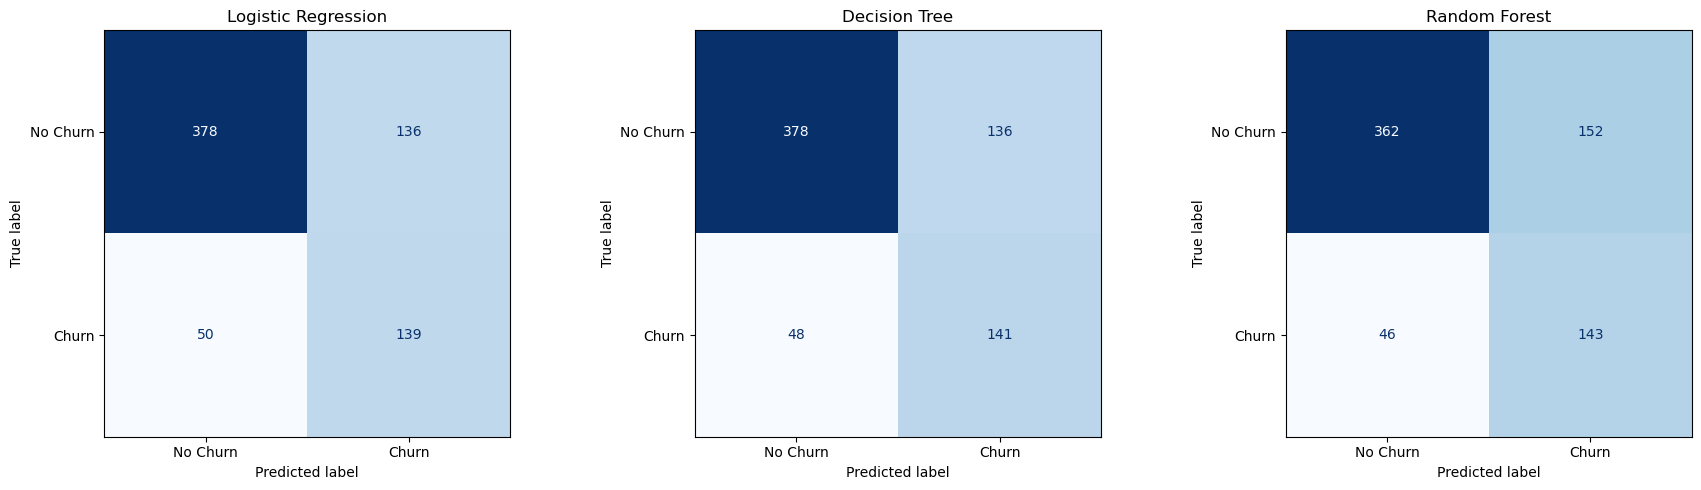

In [89]:
models = {
    'Logistic Regression': Logistic,
    'Decision Tree': DecisionTree,
    'Random Forest': forest
}
 
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
 
for ax, (name, model) in zip(axes, models.items()):
    y_pred = model.predict(x_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['No Churn', 'Churn'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(name)
 
plt.tight_layout()
plt.show()

### ROC Curve Comparison

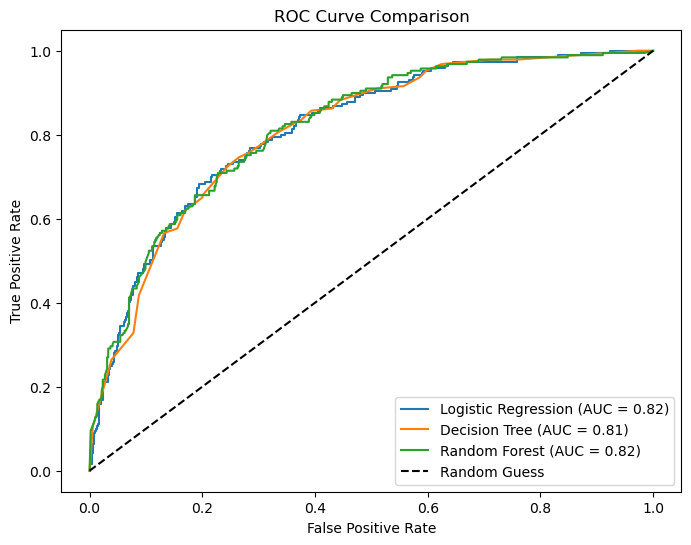

In [90]:
plt.figure(figsize=(8, 6))
 
for name, model in models.items():
    y_prob = model.predict_proba(x_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.2f})')
 
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()

### Feature Importance (Random Forest)

C:\Users\Lenovo LOQ\AppData\Local\Temp\ipykernel_30152\3032265782.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importance.values, y=feature_importance.index, palette='Set2')


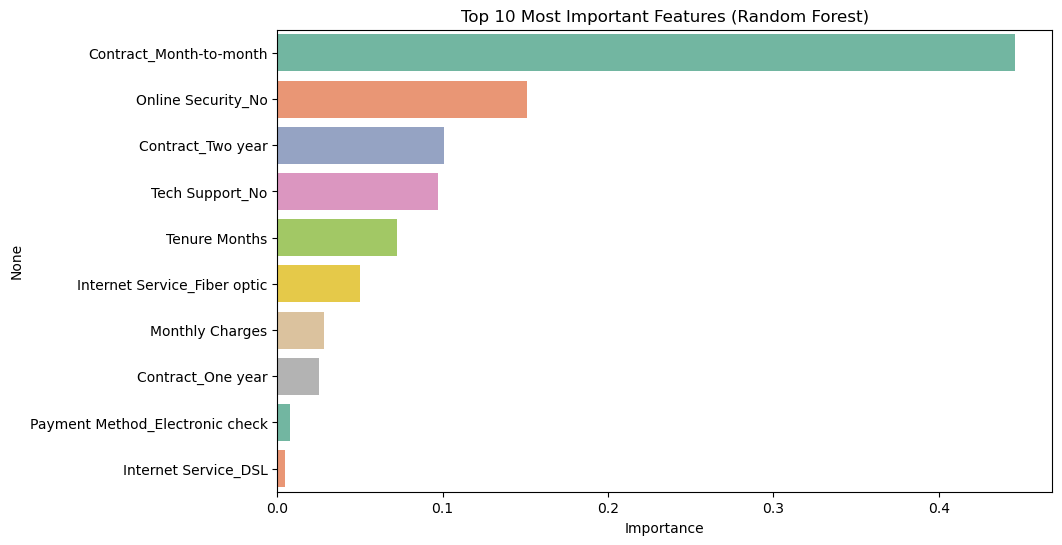

In [91]:
feature_importance = pd.Series(
    forest.best_estimator_.feature_importances_,
    index=x_train.columns
).sort_values(ascending=False)[:10]
 
plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importance.values, y=feature_importance.index, palette='Set2')
plt.title('Top 10 Most Important Features (Random Forest)')
plt.xlabel('Importance')
plt.show()

### Save the best model + preprocessing objects

In [95]:
best_model = forest.best_estimator_
 
joblib.dump(best_model, 'churn_model.pkl')
joblib.dump(en, 'onehot_encoder.pkl')      
joblib.dump(scaler, 'scaler.pkl')          
joblib.dump(labelEncoder, 'label_encoder.pkl')  

['label_encoder.pkl']